Quantity Stats:
 count    401604.000000
mean         12.183273
std         250.283037
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64 

UnitPrice Stats:
 count    401604.000000
mean          3.474064
std          69.764035
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max       38970.000000
Name: UnitPrice, dtype: float64 

Sales Stats:
 count    401604.000000
mean         20.613638
std         430.352218
min     -168469.600000
25%           4.250000
50%          11.700000
75%          19.800000
max      168469.600000
Name: Sales, dtype: float64 



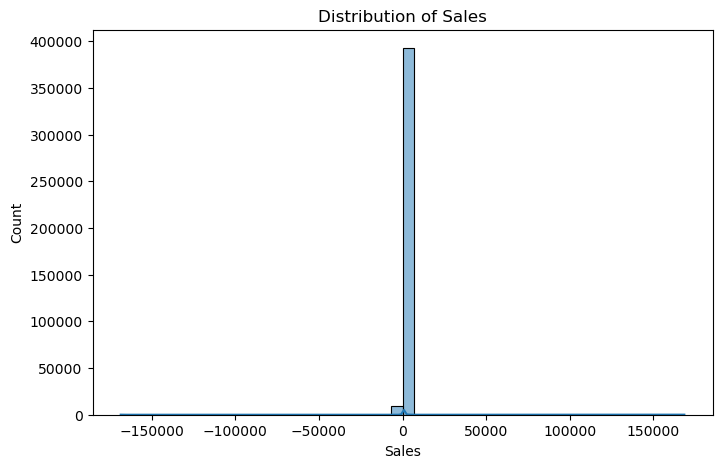

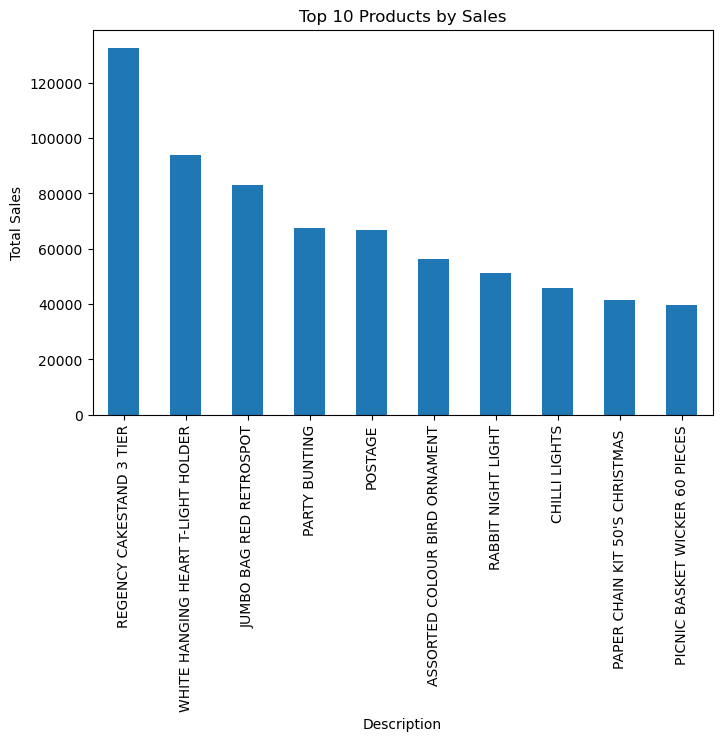

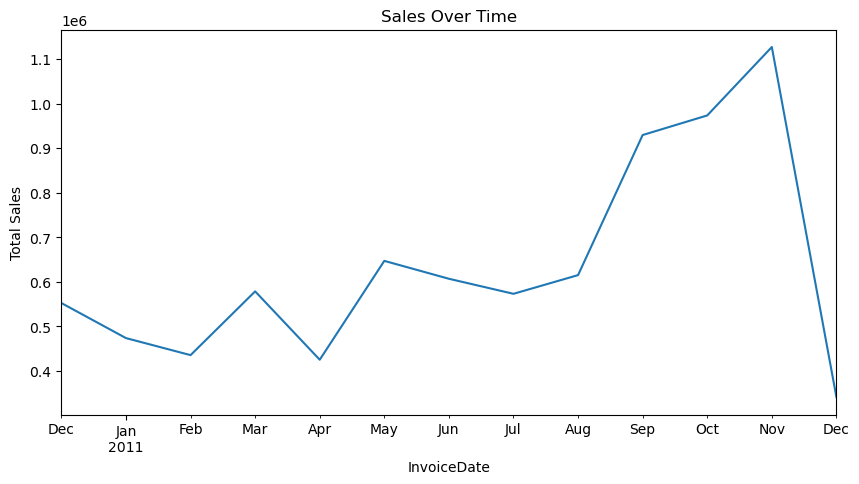


 Key Business Insights 

1. The country with the highest sales is: United Kingdom
2. Peak sales occur in: 2011-11
3. The best-selling product is: REGENCY CAKESTAND 3 TIER
4. The average order value is: 373.07
5. There are 4372 unique customers, with many repeat purchases across 401604 transactions.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")


df.drop_duplicates(inplace=True)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

df = df.dropna(subset=['CustomerID'])

df['Sales'] = df['Quantity'] * df['UnitPrice']

print("Quantity Stats:\n", df['Quantity'].describe(), "\n")
print("UnitPrice Stats:\n", df['UnitPrice'].describe(), "\n")
print("Sales Stats:\n", df['Sales'].describe(), "\n")

plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("Distribution of Sales")
plt.show()

plt.figure(figsize=(8,5))
df.groupby('Description')['Sales'].sum().nlargest(10).plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.ylabel("Total Sales")
plt.show()

plt.figure(figsize=(10,5))
df.groupby(df['InvoiceDate'].dt.to_period('M'))['Sales'].sum().plot(kind='line')
plt.title("Sales Over Time")
plt.ylabel("Total Sales")
plt.show()

df.to_csv("cleaned_data.csv", index=False)

print("\n Key Business Insights \n")

top_country = df.groupby('Country')['Sales'].sum().idxmax()
print(f"1. The country with the highest sales is: {top_country}")

monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Sales'].sum()
peak_month = monthly_sales.idxmax()
print(f"2. Peak sales occur in: {peak_month}")

top_product = df.groupby('Description')['Sales'].sum().idxmax()
print(f"3. The best-selling product is: {top_product}")

avg_order_value = df.groupby('InvoiceNo')['Sales'].sum().mean()
print(f"4. The average order value is: {avg_order_value:.2f}")

unique_customers = df['CustomerID'].nunique()
total_customers = df['CustomerID'].count()
print(f"5. There are {unique_customers} unique customers, "
      f"with many repeat purchases across {total_customers} transactions.")
